# 04 · Causal mediation — does ΔLEDD mediate the DBS effect on Δpain?

**Setup:** use the same 74 patients with both pre [−12,0] and post [+6,+18] NP1PAIN means (notebook 01).
Compute per-patient ΔLEDD over the same windows.

**Model:** treat DBS (binary) as exposure, ΔLEDD as continuous mediator, ΔNP1PAIN as continuous outcome. Use `mediation::mediate()` (quasi-Bayesian bootstrap) to decompose ACME + ADE + total effect.

**Key question:** is the DBS → reduced pain worsening effect driven by post-DBS LEDD reduction, or does it persist after accounting for medication changes?

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({ library(dplyr); library(tidyr); library(ggplot2); library(mediation) })

df <- readRDS(file.path(OUT_OBJ, "pain_long.rds"))
delta_pain <- readRDS(file.path(OUT_OBJ, "pain_delta_responder.rds"))

# ΔLEDD over the same windows — requires LEDD column in df
cat("LEDD column present:", "LEDD" %in% names(df), "\n")
stopifnot("LEDD" %in% names(df))

ledd_delta <- split_pre_post(df, var = "LEDD",
                             windows = list(pre = c(-12, 0), post = c(6, 18))) %>%
  dplyr::rename(pre_ledd = pre_val, post_ledd = post_val, delta_ledd = delta) %>%
  dplyr::select(PATNO, pre_ledd, post_ledd, delta_ledd)

dat <- delta_pain %>%
  dplyr::select(PATNO, will_receive_dbs, delta_pain = delta) %>%
  dplyr::inner_join(ledd_delta, by = "PATNO") %>%
  dplyr::mutate(dbs = as.integer(will_receive_dbs))
cat("Mediation analytic n:", nrow(dat), "\n")
print(dat %>% dplyr::group_by(will_receive_dbs) %>%
  dplyr::summarise(n = dplyr::n(),
                   mean_delta_pain = mean(delta_pain),
                   mean_delta_ledd = mean(delta_ledd),
                   median_delta_ledd = stats::median(delta_ledd), .groups = "drop"))

LEDD column present: TRUE 


Mediation analytic n: 74 


# A tibble: 2 × 5
  will_receive_dbs     n mean_delta_pain mean_delta_ledd median_delta_ledd
  <lgl>            <int>           <dbl>           <dbl>             <dbl>
1 FALSE               34          0.548            -6.70              19.8
2 TRUE                40         -0.0380           48.4                9.1


In [2]:
# Does DBS affect ΔLEDD? (mediator model "a" path)
m_med <- stats::lm(delta_ledd ~ dbs, data = dat)
print(summary(m_med)$coefficients)

# Does DBS + ΔLEDD predict Δpain?  (outcome model "b" and direct-effect "c'")
m_out <- stats::lm(delta_pain ~ dbs + delta_ledd, data = dat)
print(summary(m_out)$coefficients)

             Estimate Std. Error    t value  Pr(>|t|)
(Intercept) -6.699902   55.92878 -0.1197935 0.9049804
dbs         55.104137   76.07137  0.7243742 0.4711834


                 Estimate   Std. Error    t value    Pr(>|t|)
(Intercept)  0.5503518068 0.1735232443  3.1716316 0.002239306
dbs         -0.6038604837 0.2368519821 -2.5495268 0.012947879
delta_ledd   0.0003193784 0.0003656055  0.8735601 0.385302969


In [3]:
# Causal mediation (quasi-Bayesian, 2000 sims)
set.seed(42)
med <- mediation::mediate(m_med, m_out,
                          treat = "dbs", mediator = "delta_ledd",
                          sims = 2000)
summary(med)

effects <- tibble::tibble(
  effect = c("ACME (indirect via ΔLEDD)", "ADE (direct)", "Total", "Prop. mediated"),
  estimate = c(med$d.avg, med$z.avg, med$tau.coef, med$n.avg),
  ci_lo    = c(med$d.avg.ci[1], med$z.avg.ci[1], med$tau.ci[1], med$n.avg.ci[1]),
  ci_hi    = c(med$d.avg.ci[2], med$z.avg.ci[2], med$tau.ci[2], med$n.avg.ci[2]),
  p        = c(med$d.avg.p,   med$z.avg.p,   med$tau.p,   med$n.avg.p)
)
print(effects)
save_table(effects, "mediation_effects")


Causal Mediation Analysis 

Quasi-Bayesian Confidence Intervals

                Estimate 95% CI Lower 95% CI Upper p-value   
ACME            0.018686    -0.055928     0.134587   0.655   
ADE            -0.612404    -1.061588    -0.154191   0.006 **
Total Effect   -0.593718    -1.046191    -0.122604   0.012 * 
Prop. Mediated -0.015371    -0.354261     0.113804   0.663   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Sample Size Used: 74 


Simulations: 2000 


# A tibble: 4 × 5
  effect                    estimate   ci_lo  ci_hi     p
  <chr>                        <dbl>   <dbl>  <dbl> <dbl>
1 ACME (indirect via ΔLEDD)   0.0187 -0.0559  0.135 0.655
2 ADE (direct)               -0.612  -1.06   -0.154 0.006
3 Total                      -0.594  -1.05   -0.123 0.012
4 Prop. mediated             -0.0154 -0.354   0.114 0.663


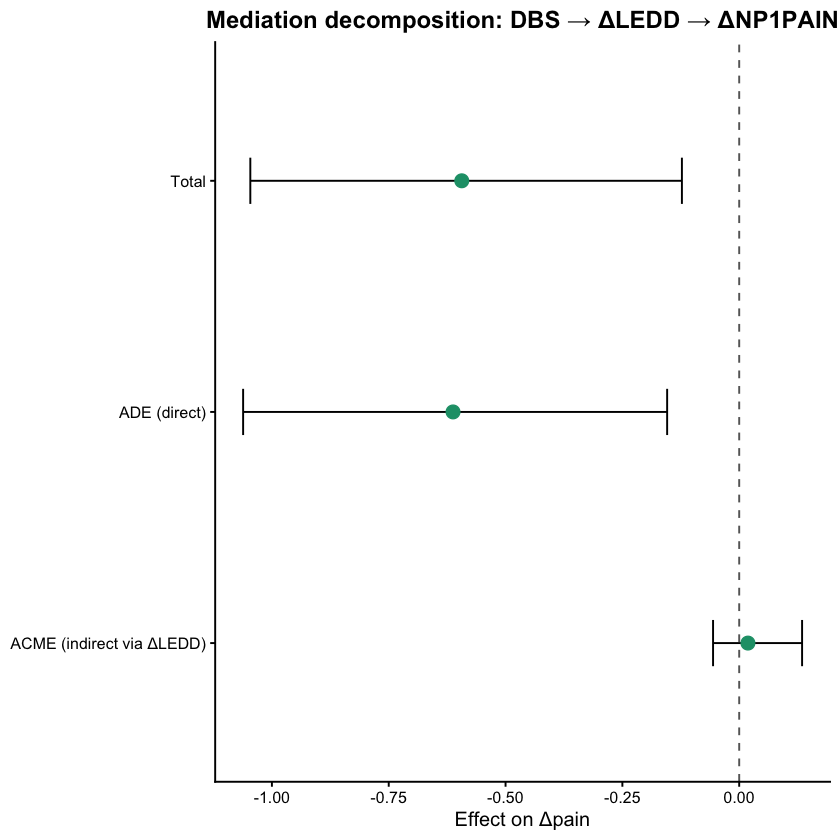

In [4]:
eff_plot <- effects %>% dplyr::filter(effect != "Prop. mediated")
p_med <- ggplot(eff_plot, aes(x = estimate, y = effect)) +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey40") +
  geom_errorbar(aes(xmin = ci_lo, xmax = ci_hi), width = 0.2, orientation = "y") +
  geom_point(size = 3.5, colour = "#1b9e77") +
  labs(title = "Mediation decomposition: DBS → ΔLEDD → ΔNP1PAIN",
       x = "Effect on Δpain", y = NULL) +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5))
p_med
save_fig(p_med, "Fig13_mediation_effects", width = 6.5, height = 3.8)

In [5]:
# Sensitivity to unmeasured confounding of mediator-outcome relation
sens <- mediation::medsens(med, rho.by = 0.05, effect.type = "indirect", sims = 500)
cat("Sensitivity: rho at which ACME = 0:\n")
print(sens$err.cr.d)
save_object(med, "mediation_fit")
save_object(sens, "mediation_sensitivity")

Sensitivity: rho at which ACME = 0:


[1] 0.1
